In [3]:
# Import libraries

import numpy as np
import matplotlib.pyplot as plt
import mglearn
import tensorflow as tf


/home/ip/.local/lib/python3.8/site-packages/pandas/core/computation/expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
2026-08-12 10:21:11.547943: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-12 10:21:11.671580: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-08-12 10:21:12.475919: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-08-12 10:21:12.480322: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical oper

In [5]:
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense

In [7]:
np.random.seed(180)
tf.random.set_seed(180)

In [8]:
people = fetch_lfw_people(
min_faces_per_person=20,
resize=0.7
)
print(people.data.shape)
print(people.target.shape)
image_shape = people.images[0].shape

(3023, 5655)
(3023,)


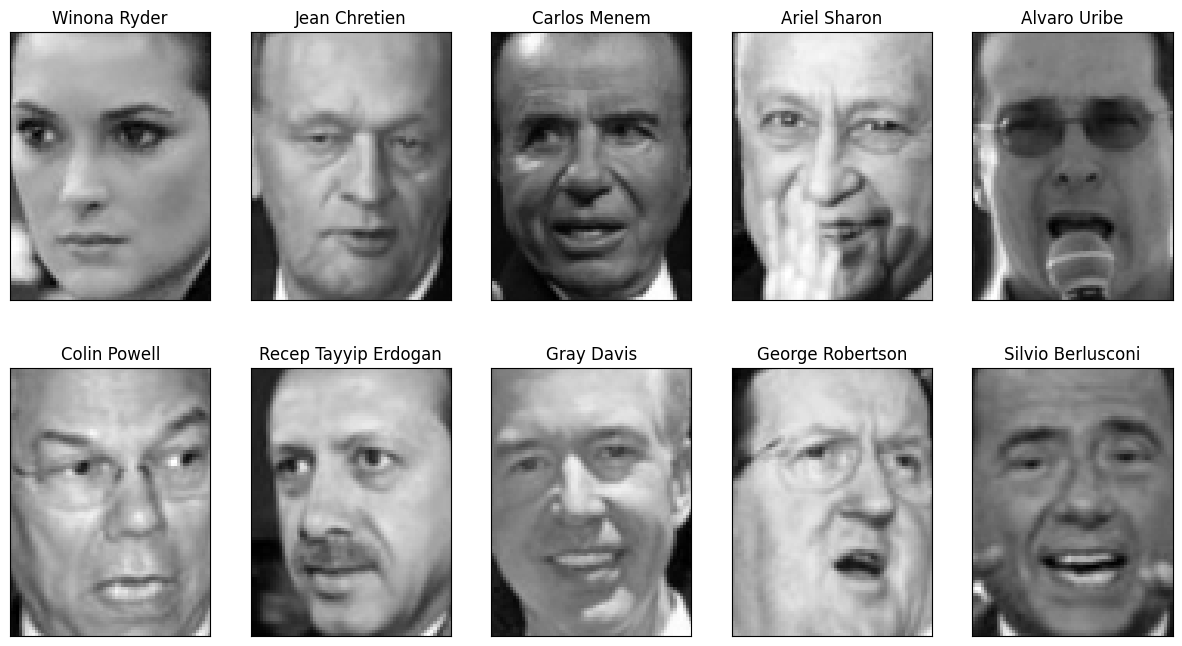

In [16]:
fig, axes = plt.subplots(
    2,
    5,
    figsize=(15, 8),
    subplot_kw={'xticks': (), 'yticks': ()}
)

for target, image, ax in zip(
    y_people[:10],
    X_people[:10],
    axes.ravel()
):
    ax.imshow(image.reshape(people.images.shape[1:]), cmap='gray')
    ax.set_title(people.target_names[target])

plt.show()


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
people.data,
people.target,
test_size=0.2,
random_state=20
)
y_train = y_train.astype(int)
y_test = y_test.astype(int)
batch_size = len(X_train)
print(
X_train.shape,
y_train.shape,
y_test.shape
)
print(
"people.images.shape: {}".format(
people.images.shape
)
)
print(
"Number of classes: {}".format(
len(people.target_names)
)
)

(2418, 5655) (2418,) (605,)
people.images.shape: (3023, 87, 65)
Number of classes: 62


In [12]:
counts = np.bincount(people.target)

for i, (count, name) in enumerate(
    zip(counts, people.target_names)
):
    print(
        "{0:25} {1:3}".format(name, count),
        end=" "
    )

    if (i + 1) % 3 == 0:
        print()


Alejandro Toledo           39 Alvaro Uribe               35 Amelie Mauresmo            21 
Andre Agassi               36 Angelina Jolie             20 Ariel Sharon               77 
Arnold Schwarzenegger      42 Atal Bihari Vajpayee       24 Bill Clinton               29 
Carlos Menem               21 Colin Powell              236 David Beckham              31 
Donald Rumsfeld           121 George Robertson           22 George W Bush             530 
Gerhard Schroeder         109 Gloria Macapagal Arroyo    44 Gray Davis                 26 
Guillermo Coria            30 Hamid Karzai               22 Hans Blix                  39 
Hugo Chavez                71 Igor Ivanov                20 Jack Straw                 28 
Jacques Chirac             52 Jean Chretien              55 Jennifer Aniston           21 
Jennifer Capriati          42 Jennifer Lopez             21 Jeremy Greenstock          24 
Jiang Zemin                20 John Ashcroft              53 John Negroponte            31 

In [18]:
mask = np.zeros(
    people.target.shape,
    dtype=np.bool_
)

for target in np.unique(people.target):
    mask[
        np.where(people.target == target)[0][:50]
    ] = True

X_people = people.data[mask]
y_people = people.target[mask]

# Scale pixel values
X_people = X_people / 255.0


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
X_people,
y_people,
stratify=y_people,
random_state=0
)
# KNN without PCA
knn = KNeighborsClassifier(
n_neighbors=1
)
knn.fit(
X_train,
y_train
)
print(
"Test set score of 1-nn: {:.2f}".format(
knn.score(X_test,
y_test
)
)
)

Test set score of 1-nn: 0.22


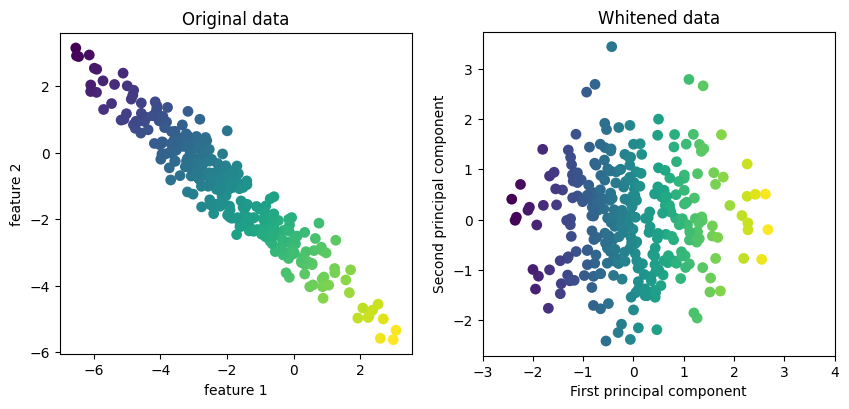

In [20]:
mglearn.plots.plot_pca_whitening()
plt.show()

In [22]:
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier

pca = PCA(
    n_components=100,
    whiten=True,
    random_state=0
).fit(X_train)

X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

print(
    "X_train_pca.shape: {}".format(
        X_train_pca.shape
    )
)

# KNN with PCA
knn = KNeighborsClassifier(
    n_neighbors=1
)

knn.fit(
    X_train_pca,
    y_train
)

print(
    "Test set accuracy: {:.2f}".format(
        knn.score(
            X_test_pca,
            y_test
        )
    )
)

print(
    "pca.components_.shape: {}".format(
        pca.components_.shape
    )
)


X_train_pca.shape: (1547, 100)
Test set accuracy: 0.30
pca.components_.shape: (100, 5655)


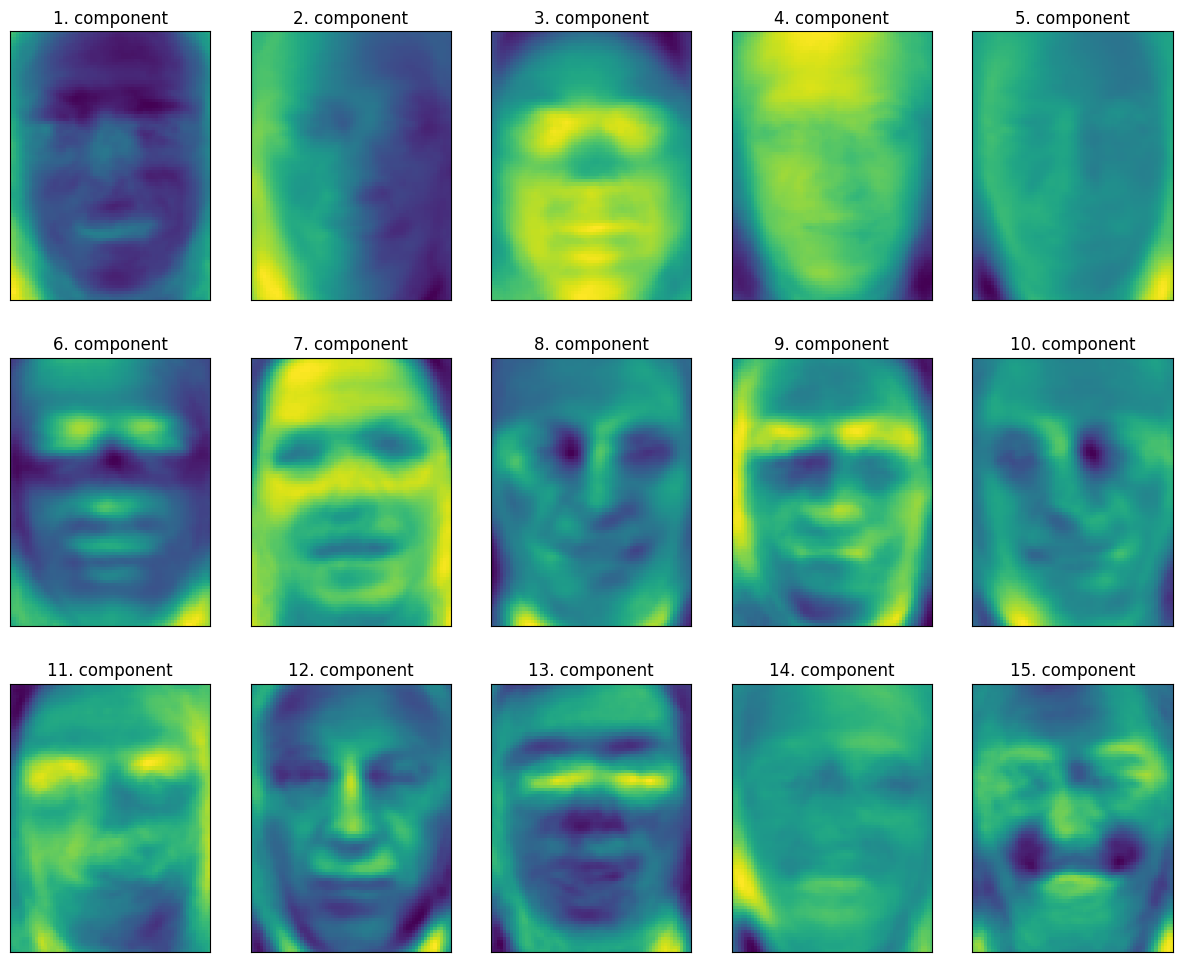

In [24]:
image_shape = people.images.shape[1:]

fig, axes = plt.subplots(
    3,
    5,
    figsize=(15, 12),
    subplot_kw={'xticks': (), 'yticks': ()}
)

for i, (component, ax) in enumerate(
    zip(pca.components_, axes.ravel())
):
    ax.imshow(
        component.reshape(image_shape),
        cmap='viridis'
    )
    ax.set_title(
        "{}. component".format(i + 1)
    )

plt.show()


In [25]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(
X_train_pca
)
X_test_scaled = scaler.transform(
X_test_pca
)

In [26]:
model = Sequential([
Input(
shape=(100,)
),
Dense(
300,
activation='relu'
),
Dense(
100,
activation='relu'
),
Dense(
len(np.unique(y_train)),
activation='softmax'
)
])

In [27]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [28]:
history = model.fit( X_train_scaled,y_train,batch_size=50,epochs=20,shuffle=False, verbose=1)

Epoch 1/20
31/31 [==============================] - 0s 2ms/step - loss: 4.1195 - accuracy: 0.0233
Epoch 2/20
31/31 [==============================] - 0s 4ms/step - loss: 4.0831 - accuracy: 0.0297
Epoch 3/20
31/31 [==============================] - 0s 786us/step - loss: 4.0580 - accuracy: 0.0381
Epoch 4/20
31/31 [==============================] - 0s 910us/step - loss: 4.0306 - accuracy: 0.0608
Epoch 5/20
31/31 [==============================] - 0s 892us/step - loss: 3.9989 - accuracy: 0.0672
Epoch 6/20
31/31 [==============================] - 0s 795us/step - loss: 3.9639 - accuracy: 0.0789
Epoch 7/20
31/31 [==============================] - 0s 818us/step - loss: 3.9102 - accuracy: 0.1144
Epoch 8/20
31/31 [==============================] - 0s 888us/step - loss: 3.8440 - accuracy: 0.1325
Epoch 9/20
31/31 [==============================] - 0s 766us/step - loss: 3.7635 - accuracy: 0.1610
Epoch 10/20
31/31 [==============================] - 0s 845us/step - loss: 3.6636 - accuracy: 0.1907
Epo

In [29]:
loss, accuracy = model.evaluate( X_test_scaled,y_test,verbose=1)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

17/17 [==============================] - 0s 756us/step - loss: 2.7352 - accuracy: 0.3682
Test Loss: 2.735226631164551
Test Accuracy: 0.3682170510292053
